# Berry phases, Berry curvatures, Chern numbers and Z2 invariants

The Chern number characterizes a two-dimensional insulator with broken time-reversal symmetry,

$$
C = \frac{1}{2\pi}\int \Omega(\mathbf k)\,d^2\mathbf k
$$

where $\Omega(\mathbf k)$ is the Berry curvature of the occupied bands (`h.get_chern()`, by
default a Wilson-loop evaluation of $\Omega$ over a k-mesh). With time-reversal symmetry restored
(e.g. spin-orbit coupling instead of a Haldane mass), the relevant $\mathbb{Z}_2$-valued invariant
is `topology.z2_invariant`, obtained by pumping hybrid Wannier centers across the Brillouin zone.

Chern number (Haldane) = 2.0000000000000058


Z2 invariant (Kane-Mele) = -1


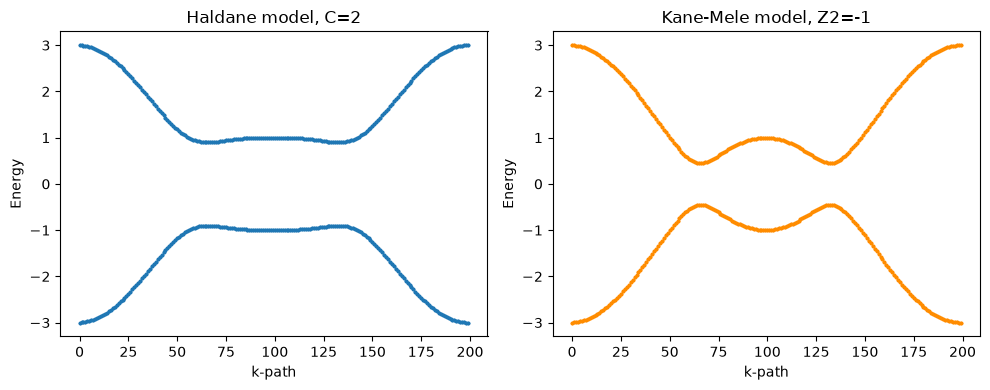

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology

# Chern number: Haldane model (broken time-reversal symmetry)
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian()
h.add_haldane(0.2)
C = h.get_chern(nk=30)
print("Chern number (Haldane) =",C)

# Z2 invariant: Kane-Mele model (time-reversal symmetric spin-orbit coupling)
g2 = geometry.honeycomb_lattice()
h2 = g2.get_hamiltonian()
h2.add_soc(0.1)
z2 = topology.z2_invariant(h2,nk=30,nt=30)
print("Z2 invariant (Kane-Mele) =",z2)

(k,e) = h.get_bands(nk=200)
(k2,e2) = h2.get_bands(nk=200)
fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].scatter(k,e,s=3) ; axs[0].set_title(f"Haldane model, C={C:.0f}")
axs[0].set_xlabel("k-path") ; axs[0].set_ylabel("Energy")
axs[1].scatter(k2,e2,s=3,c="darkorange") ; axs[1].set_title(f"Kane-Mele model, Z2={z2}")
axs[1].set_xlabel("k-path") ; axs[1].set_ylabel("Energy")
plt.tight_layout()
plt.show()

### Where the Chern number comes from
We will now look at the Berry curvature of the occupied bands over the Brillouin zone, with
`h.get_berry_curvature()`. For a weak Haldane coupling the curvature concentrates at the two
valleys K and K', where the gap is smallest, with the same sign in both, so that it integrates to a
non-zero Chern number. A sublattice imbalance opens a gap of its own, with opposite signs in the
two valleys, and the Chern number as a function of the two terms shows the topological phase only
where the Haldane term wins.

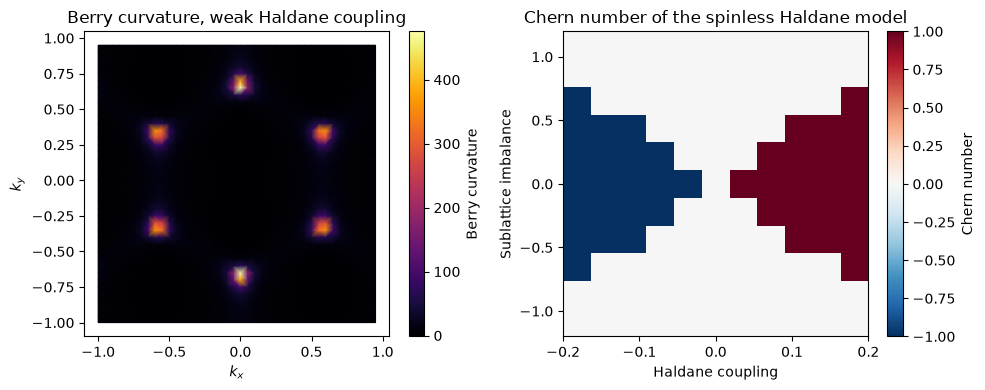

In [2]:
hw = g.get_hamiltonian() # honeycomb lattice
hw.add_haldane(0.05) # weak Haldane coupling
(kx,ky,omega) = hw.get_berry_curvature(nk=40,write=False) # Berry curvature on a k-mesh

ms = np.linspace(-1.2,1.2,11) # sublattice imbalance
t2s = np.linspace(-0.2,0.2,11) # Haldane coupling
Cs = np.zeros((len(ms),len(t2s))) # Chern numbers
for (i,m) in enumerate(ms):
    for (j,t2) in enumerate(t2s):
        hi = g.get_hamiltonian(has_spin=False) # spinless honeycomb lattice
        hi.add_haldane(t2) # Haldane coupling
        hi.add_sublattice_imbalance(m) # sublattice imbalance
        Cs[i,j] = hi.get_chern(nk=10) # Chern number

fig,axs = plt.subplots(1,2,figsize=(10,4))
s = axs[0].tripcolor(kx,ky,omega,cmap="inferno",shading="gouraud")
fig.colorbar(s,ax=axs[0],label="Berry curvature")
axs[0].set_aspect("equal") ; axs[0].set_title("Berry curvature, weak Haldane coupling")
axs[0].set_xlabel("$k_x$") ; axs[0].set_ylabel("$k_y$")
s = axs[1].imshow(Cs,origin="lower",aspect="auto",cmap="RdBu_r",vmin=-1,vmax=1,
        extent=[t2s[0],t2s[-1],ms[0],ms[-1]])
fig.colorbar(s,ax=axs[1],label="Chern number")
axs[1].set_xlabel("Haldane coupling") ; axs[1].set_ylabel("Sublattice imbalance")
axs[1].set_title("Chern number of the spinless Haldane model")
plt.tight_layout()
plt.show()